# AG News Auto-Triage: Deep Learning for Business Operations
## Table of Contents
1. [Business Problem & Dataset Description](#1-business-problem--dataset-description)
2. [Exploratory Data Analysis](#2-exploratory-data-analysis)
3. [Preprocessing Pipeline](#3-preprocessing-pipeline)
4. [Model from Scratch (Keras)](#4-model-from-scratch-keras)
5. [Pretrained Model (DistilBERT)](#5-pretrained-model-distilbert)
6. [Hyperparameter Tuning](#6-hyperparameter-tuning)
7. [Model Evaluation & Interpretation](#7-model-evaluation--interpretation)
8. [Final Report](#8-final-report)

# 1. Business Problem & Dataset Description
## 1.1 Business Context
- A financial services firm receives 5,000 news articles daily.
- Analysts manually route each article to World, Sports, Business, or Sci/Tech desks.
- Time per article: 90 seconds. Analyst rate: $35/hour. Trading days: 250/year.
- Total labor cost: 5,000 × 90s × $35/hr × 250 days = $1.09M/year.
- A DL model automating 85% of routing saves ~$930K/year.

## 1.2 Dataset Reference
- Source: https://www.kaggle.com/datasets/amananandrai/ag-news-classification-dataset/data
- 120,000 training samples, 7,600 test samples.
- 4 classes: World, Sports, Business, Sci/Tech.
- Features: article title + description (text), label (0-3).

In [21]:
# Imports and environment setup
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
import time

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

from transformers import DistilBertTokenizerFast
from transformers import TFDistilBertForSequenceClassification
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Move to project root so all paths work correctly
if 'notebooks' in os.getcwd():
    os.chdir(os.path.abspath(os.path.join(os.getcwd(), '..')))

# Allow importing from src/ folder
sys.path.append(os.path.join(os.getcwd(), 'src'))

# Verify environment
print(f"TensorFlow version: {tf.__version__}")
print(f"GPU Available: {tf.config.list_physical_devices('GPU')}")

TensorFlow version: 2.10.0
GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


# 2. Exploratory Data Analysis

## 2.1 Load Data

In [2]:
# We load the CSVs saved by src/setup_data.py
train_df = pd.read_csv('data/train.csv')
test_df = pd.read_csv('data/test.csv')

print("=== TRAIN SET ===")
print(train_df.head(2))
print(f"\nShape: {train_df.shape}")
print(f"\nColumns: {train_df.columns.tolist()}")

print("\n=== TEST SET ===")
print(test_df.head(2))
print(f"\nShape: {test_df.shape}")


=== TRAIN SET ===
   class_index                                              title  \
0            3  Wall St. Bears Claw Back Into the Black (Reuters)   
1            3  Carlyle Looks Toward Commercial Aerospace (Reu...   

                                         description  category  
0  Reuters - Short-sellers, Wall Street's dwindli...  Business  
1  Reuters - Private investment firm Carlyle Grou...  Business  

Shape: (120000, 4)

Columns: ['class_index', 'title', 'description', 'category']

=== TEST SET ===
   class_index                                              title  \
0            3                  Fears for T N pension after talks   
1            4  The Race is On: Second Private Team Sets Launc...   

                                         description  category  
0  Unions representing workers at Turner   Newall...  Business  
1  SPACE.com - TORONTO, Canada -- A second\team o...  Sci/Tech  

Shape: (7600, 4)


## 2.2 Class Distribution

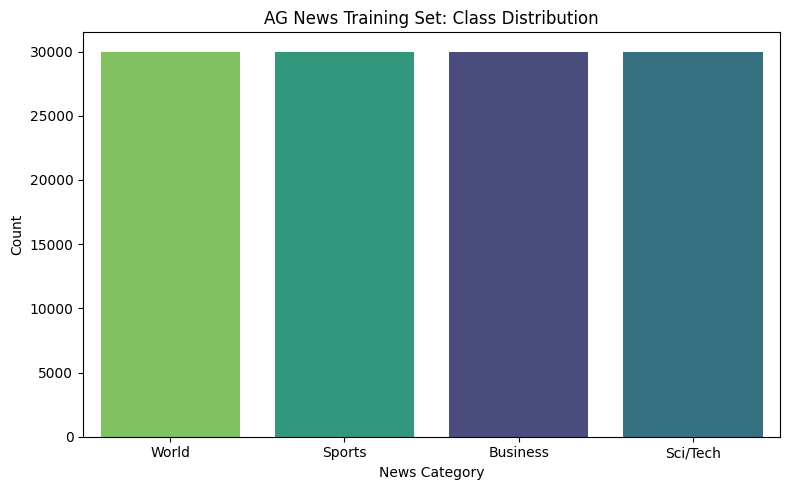


Class counts (train):
category
Business    30000
Sci/Tech    30000
Sports      30000
World       30000
Name: count, dtype: int64


In [3]:
# Visualize how balanced the dataset is
plt.figure(figsize=(8, 5))
order = ['World', 'Sports', 'Business', 'Sci/Tech']
sns.countplot(
    data=train_df,
    x='category',
    order=order,
    hue='category',
    palette='viridis',
    legend=False,
)
plt.title('AG News Training Set: Class Distribution')
plt.xlabel('News Category')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('reports/class_distribution.png')
plt.show()

print("\nClass counts (train):")
print(train_df['category'].value_counts())


## 2.3 Text Length Analysis

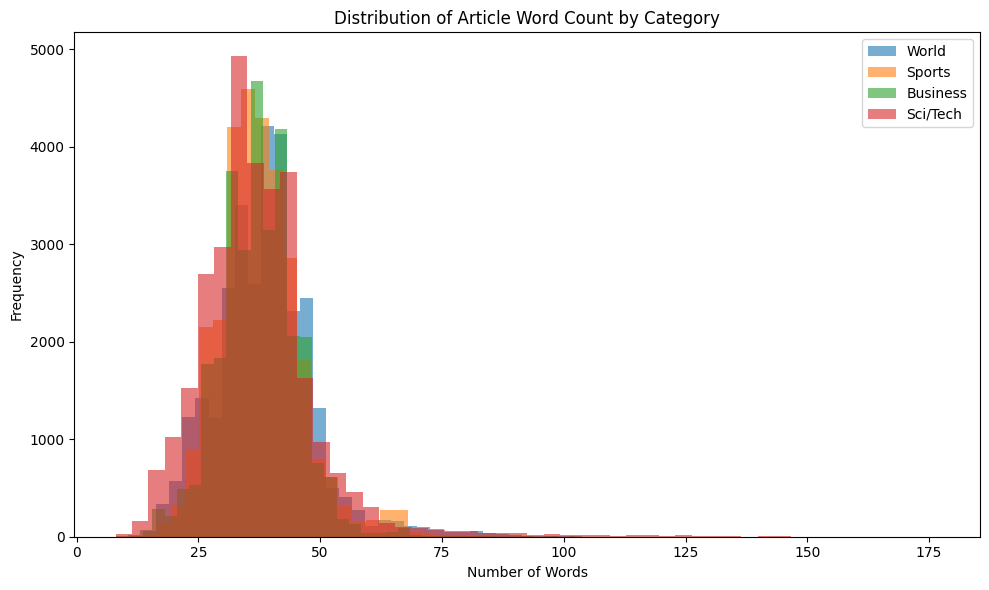


Average word count per category:
category
Business    37.5
Sci/Tech    37.2
Sports      37.8
World       38.9
Name: word_count, dtype: float64


In [4]:
# Combine title + description for full article text
train_df['full_text'] = train_df['title'].astype(str) + ' ' + train_df['description'].astype(str)
test_df['full_text'] = test_df['title'].astype(str) + ' ' + test_df['description'].astype(str)

# Calculate length in words
train_df['word_count'] = train_df['full_text'].apply(lambda x: len(str(x).split()))

plt.figure(figsize=(10, 6))
for category in order:
    subset = train_df[train_df['category'] == category]['word_count']
    plt.hist(subset, bins=50, alpha=0.6, label=category)
plt.title('Distribution of Article Word Count by Category')
plt.xlabel('Number of Words')
plt.ylabel('Frequency')
plt.legend()
plt.tight_layout()
plt.savefig('reports/class_distribution.png')
plt.show()

print(f"\nAverage word count per category:")
print(train_df.groupby('category')['word_count'].mean().round(1))


## 2.4 Word Clouds / Common Words

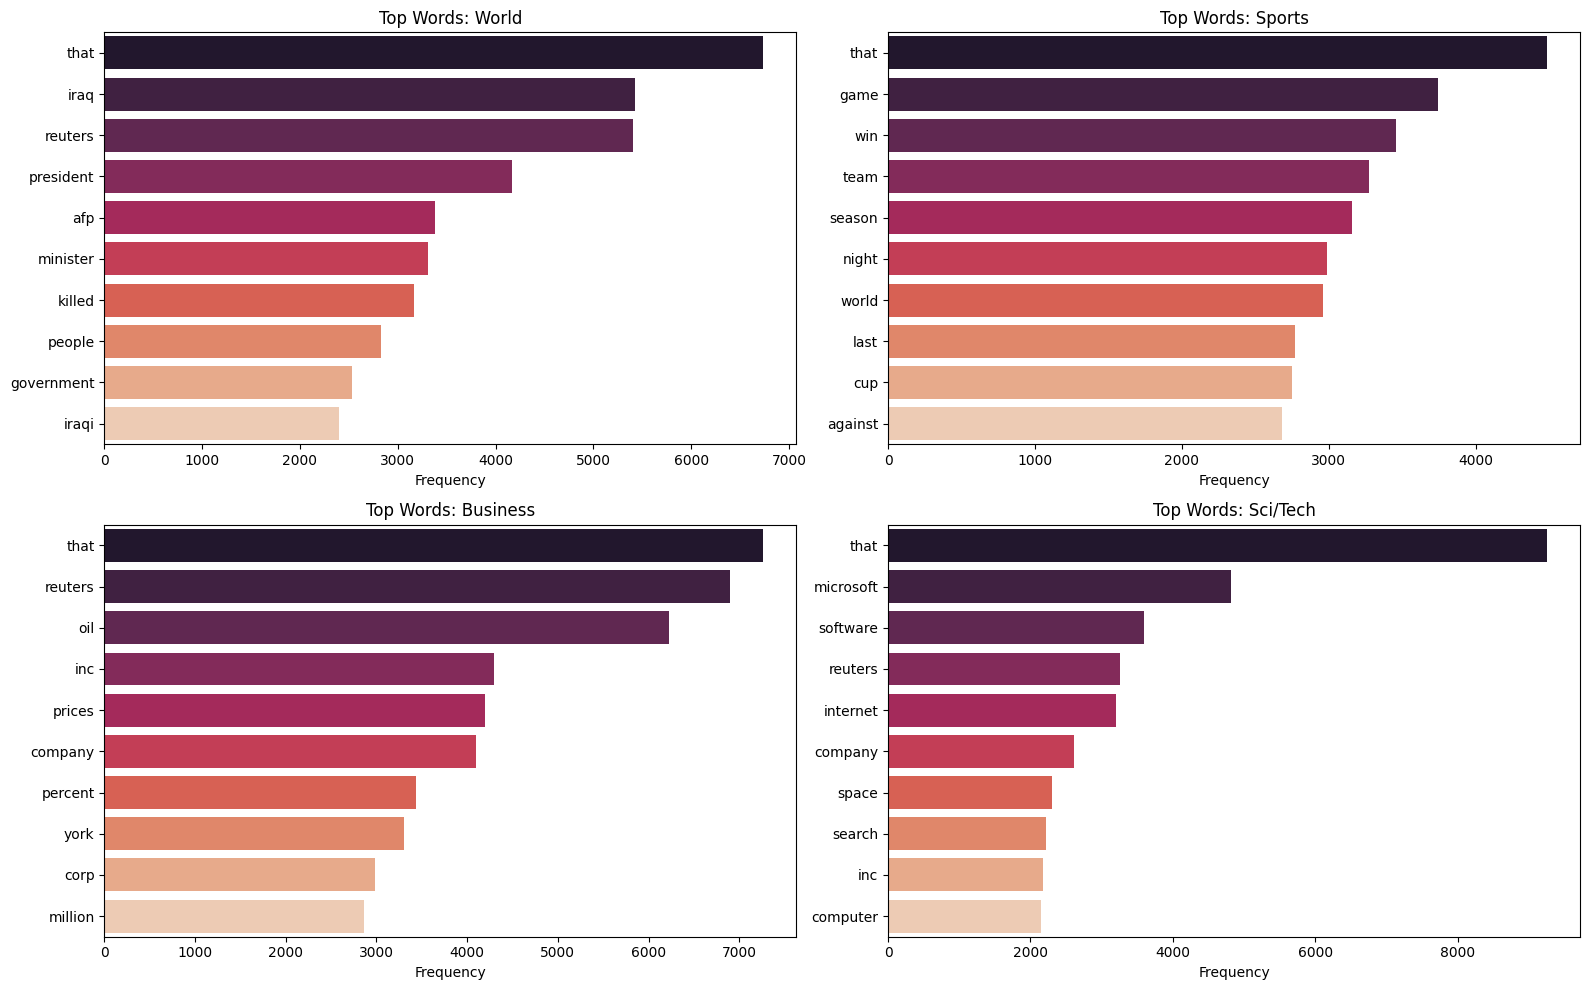

EDA complete. Plots saved to reports/


In [5]:
# We use Python's Counter to find top words after basic cleaning
import re
from collections import Counter

def get_top_words(texts, n=10):
    """
    Join a collection of texts, extract alphabetic words, and count frequencies.

    Steps performed:
      1. Concatenate all texts into one lower-case string.
      2. Remove non-alphabetic characters (keep only a-z and spaces).
      3. Filter out a manual stop-word list and words shorter than 3 chars.
      4. Return the n most common remaining words with their counts.

    Parameters
    ----------
    texts : pd.Series or array-like
        Collection of text samples (e.g. article bodies for one category).
    n : int, optional
        Number of top words to return (default 10).

    Returns
    -------
    list[tuple[str, int]]
        A list of (word, count) tuples sorted by descending frequency.
    """
    all_text = ' '.join(texts.astype(str)).lower()
    # Keep only letters and spaces
    all_text = re.sub(r'[^a-z\s]', '', all_text)
    # Remove common stop words manually 
    stop_words = {'the', 'and', 'for', 'are', 'but', 'not', 'you', 'all', 'can', 'had', 'her', 'was', 'one', 'our', 'out', 'day', 'get', 'has', 'him', 'his', 'how', 'man', 'new', 'now', 'old', 'see', 'two', 'way', 'who', 'boy', 'did', 'its', 'let', 'put', 'say', 'she', 'too', 'use', 'with', 'have', 'this', 'will', 'your', 'from', 'they', 'know', 'want', 'been', 'good', 'much', 'some', 'time', 'very', 'when', 'come', 'here', 'just', 'like', 'long', 'make', 'many', 'over', 'such', 'take', 'than', 'them', 'well', 'were', 'what', 'would', 'there', 'their', 'said', 'each', 'which', 'how', 'about', 'out', 'many', 'then', 'them', 'these', 'so', 'some', 'her', 'would', 'make', 'like', 'into', 'him', 'has', 'two', 'more', 'very', 'what', 'know', 'just', 'first', 'also', 'after', 'back', 'other', 'many', 'than', 'only', 'those', 'come', 'day', 'most', 'us'}
    words = [w for w in all_text.split() if w not in stop_words and len(w) > 2]
    return Counter(words).most_common(n)

plt.figure(figsize=(16, 10))
for i, category in enumerate(order, 1):
    texts = train_df[train_df['category'] == category]['full_text']
    top_words = get_top_words(texts, n=10)
    words, counts = zip(*top_words)
    
    plt.subplot(2, 2, i)
    sns.barplot(
        x=list(counts),
        y=list(words),
        hue=list(words),
        palette='rocket',
        legend=False,
    )
    plt.title(f'Top Words: {category}')
    plt.xlabel('Frequency')
    
plt.tight_layout()
plt.savefig('reports/class_distribution.png')
plt.show()

print("EDA complete. Plots saved to reports/")


# 3. Preprocessing Pipeline

## 3.1 Text Cleaning
We combine the article title and description into a single string, then lowercase it, strip non-alphabetic characters, and collapse whitespace so the model sees clean input.

In [6]:
# Combine title + description into one field for each article.
train_df['full_text'] = train_df['title'].astype(str) + ' ' + train_df['description'].astype(str)
test_df['full_text'] = test_df['title'].astype(str) + ' ' + test_df['description'].astype(str)

# Import and apply the cleaning function from src/preprocessing
from src.preprocessing import clean_text
train_clean = train_df["full_text"].apply(clean_text)
test_clean = test_df["full_text"].apply(clean_text)

print("Sample cleaned text:")
print(train_clean.iloc[0][:200])


Sample cleaned text:
wall st bears claw back into the black reuters reuters shortsellers wall streets dwindlingband of ultracynics are seeing green again


## 3.2 Tokenization & Vocabulary Building
We fit a Keras Tokenizer **only on training data** to prevent leakage. The vocabulary is capped at 20,000 words and an `<OOV>` token handles unseen words at inference time. The fitted tokenizer is saved to `models/tokenizer.pickle` for reuse.

In [7]:
# Fit the tokenizer ONLY on training data to prevent leakage.
from src.preprocessing import build_tokenizer

tokenizer = build_tokenizer(
    train_clean,
    max_words=20000,
    save_path='models/tokenizer.pickle'
)


Tokenizer saved. Vocabulary size: 91344


## 3.3 Sequence Padding
Articles vary in length, so we pad every sequence to 128 tokens. We use **post-padding** (zeros at the end) so the LSTM reads the sentence start first.

In [8]:
# Convert texts to integer sequences and pad/truncate to fixed length.
from src.preprocessing import prepare_sequences

MAX_LEN = 128
X_train = prepare_sequences(train_clean, tokenizer, max_len=MAX_LEN)
X_test = prepare_sequences(test_clean, tokenizer, max_len=MAX_LEN)

print(f"X_train shape: {X_train.shape}")
print(f"X_test  shape: {X_test.shape}")


X_train shape: (120000, 128)
X_test  shape: (7600, 128)


## 3.4 Label Preparation
The raw AG News CSV stores labels as 1-based integers (`1` = World, `2` = Sports, `3` = Business, `4` = Sci/Tech). Keras expects 0-based one-hot vectors, so we subtract 1 and apply `to_categorical`.

In [9]:
# AG News uses 1-based labels (1-4). Subtract 1 and one-hot encode for Keras.
from tensorflow.keras.utils import to_categorical

y_train_oh = to_categorical(train_df['class_index'] - 1, num_classes=4)
y_test_oh = to_categorical(test_df['class_index'] - 1, num_classes=4)


## 3.5 Train/Validation Split
We reserve 10 % of the training data as a validation set. The split is **stratified** so each news category appears in the same proportion as the full training set.

In [10]:
# 3.5 Train/Validation Split
# 90/10 stratified split keeps class proportions identical in both sets.
from sklearn.model_selection import train_test_split

X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train_oh, test_size=0.1, random_state=42, stratify=y_train_oh
)

print(f"Train      : {X_tr.shape}")
print(f"Validation : {X_val.shape}")
print(f"Test       : {X_test.shape}")


Train      : (108000, 128)
Validation : (12000, 128)
Test       : (7600, 128)


## 3.6 Saving Arrays
We export the six final NumPy arrays (`X_train`, `y_train`, `X_val`, `y_val`, `X_test`, `y_test`) to `data/processed/` so teammates can load them directly without re-running preprocessing.

In [11]:
# Export the six final arrays so teammates can skip preprocessing.
import os
import numpy as np

save_dir = 'data/processed'
os.makedirs(save_dir, exist_ok=True)

np.save(os.path.join(save_dir, 'X_train.npy'), X_tr)
np.save(os.path.join(save_dir, 'y_train.npy'), y_tr)
np.save(os.path.join(save_dir, 'X_val.npy'), X_val)
np.save(os.path.join(save_dir, 'y_val.npy'), y_val)
np.save(os.path.join(save_dir, 'X_test.npy'), X_test)
np.save(os.path.join(save_dir, 'y_test.npy'), y_test_oh)

print(f"Arrays saved to {save_dir}/")
print(f"  Train      : {X_tr.shape}")
print(f"  Validation : {X_val.shape}")
print(f"  Test       : {X_test.shape}")
print(f"  Vocab size : {len(tokenizer.word_index)}")


Arrays saved to data/processed/
  Train      : (108000, 128)
  Validation : (12000, 128)
  Test       : (7600, 128)
  Vocab size : 91344


# 4. Model from Scratch (Keras)
## 4.1 Architecture: Embedding → BiLSTM → GlobalMaxPool → Dense → Softmax
## 4.2 Compilation & Training
## 4.3 History Tracking

In [12]:
# TODO: Import build_scratch_model from src.model_builder
# TODO: Compile with Adam, sparse_categorical_crossentropy, accuracy
# TODO: Add EarlyStopping and ReduceLROnPlateau callbacks
# TODO: Train and save history
# TODO: Plot loss/accuracy curves using src.utils

# 5. Pretrained Model (DistilBERT Fine-Tuning)

In [13]:
# Section 5: Pretrained Model (DistilBERT Fine-Tuning)

# Load the AG News dataset
train_df_bert = pd.read_csv('data/train.csv')
test_df_bert  = pd.read_csv('data/test.csv')

# Combine title and description into one text column
train_df_bert['text'] = train_df_bert['title'].astype(str) + ' ' + train_df_bert['description'].astype(str)
test_df_bert['text']  = test_df_bert['title'].astype(str)  + ' ' + test_df_bert['description'].astype(str)

# Convert labels from 1-4 to 0-3
train_labels = (pd.to_numeric(train_df_bert['class_index'], errors='coerce').fillna(1).values - 1).astype(int)
test_labels  = (pd.to_numeric(test_df_bert['class_index'],  errors='coerce').fillna(1).values - 1).astype(int)

# Remove any rows where label conversion failed
mask_train = (train_labels >= 0) & (train_labels <= 3)
mask_test  = (test_labels  >= 0) & (test_labels  <= 3)

train_df_bert = train_df_bert[mask_train].reset_index(drop=True)
test_df_bert  = test_df_bert[mask_test].reset_index(drop=True)
train_labels  = train_labels[mask_train]
test_labels   = test_labels[mask_test]

print(f"Train samples: {len(train_df_bert)}")
print(f"Test samples:  {len(test_df_bert)}")
print(f"Label range:   {train_labels.min()} to {train_labels.max()}")

Train samples: 120000
Test samples:  7600
Label range:   0 to 3


## 5.1 Tokenization for BERT

In [17]:
# 5.1 Tokenize text using DistilBERT's tokenizer

MAX_LEN = 128
BERT_MODEL = 'distilbert-base-uncased'
tokenizer_bert = DistilBertTokenizerFast.from_pretrained(BERT_MODEL)

# Tokenize training data
print("Tokenizing training data...")
train_encodings = tokenizer_bert(
    list(train_df_bert['text']),
    truncation=True,
    padding=True,
    max_length=MAX_LEN,
    return_tensors='tf'
)

# Tokenize test data
print("Tokenizing test data...")
test_encodings = tokenizer_bert(
    list(test_df_bert['text']),
    truncation=True,
    padding=True,
    max_length=MAX_LEN,
    return_tensors='tf'
)

print("Tokenization done!")
print(f"Input IDs shape: {train_encodings['input_ids'].shape}")

Tokenizing training data...
Tokenizing test data...
Tokenization done!
Input IDs shape: (120000, 128)


## 5.2 Model Setup & Layer Freezing

In [20]:
# 5.2 Model Setup & Layer Freezing

print("Loading pretrained DistilBERT model...")
model_bert = TFDistilBertForSequenceClassification.from_pretrained(
    BERT_MODEL,
    num_labels=4
)

# Freeze the first 4 transformer layers to save time and preserve what the model already learned
for layer in model_bert.distilbert.transformer.layer[:4]:
    layer.trainable = False

# Compile with a small learning rate, standard practice for fine-tuning
model_bert.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=2e-5),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)

model_bert.summary()
print("Model built successfully!")

Loading pretrained DistilBERT model...


Some weights of the PyTorch model were not used when initializing the TF 2.0 model TFDistilBertForSequenceClassification: ['vocab_transform.bias', 'vocab_projector.bias', 'vocab_layer_norm.weight', 'vocab_layer_norm.bias', 'vocab_transform.weight']
- This IS expected if you are initializing TFDistilBertForSequenceClassification from a PyTorch model trained on another task or with another architecture (e.g. initializing a TFBertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFDistilBertForSequenceClassification from a PyTorch model that you expect to be exactly identical (e.g. initializing a TFBertForSequenceClassification model from a BertForSequenceClassification model).
Some weights or buffers of the TF 2.0 model TFDistilBertForSequenceClassification were not initialized from the PyTorch model and are newly initialized: ['pre_classifier.weight', 'pre_classifier.bias', 'classifier.weight', 'classifier.bias']
You should 

Model: "tf_distil_bert_for_sequence_classification_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 distilbert (TFDistilBertMai  multiple                 66362880  
 nLayer)                                                         
                                                                 
 pre_classifier (Dense)      multiple                  590592    
                                                                 
 classifier (Dense)          multiple                  3076      
                                                                 
 dropout_39 (Dropout)        multiple                  0         
                                                                 
Total params: 66,956,548
Trainable params: 38,605,060
Non-trainable params: 28,351,488
_________________________________________________________________
Model built successfully!


## 5.3 Fine-Tuning

In [22]:
# 5.3 Fine-tune the model

callbacks = [
    EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=1, min_lr=1e-7)
]

# Use a subset of the data to keep training time reasonable
TRAIN_SIZE = 10000
VAL_SIZE   = 2000

train_input = {
    'input_ids':      train_encodings['input_ids'][:TRAIN_SIZE],
    'attention_mask': train_encodings['attention_mask'][:TRAIN_SIZE]
}
val_input = {
    'input_ids':      train_encodings['input_ids'][TRAIN_SIZE:TRAIN_SIZE+VAL_SIZE],
    'attention_mask': train_encodings['attention_mask'][TRAIN_SIZE:TRAIN_SIZE+VAL_SIZE]
}

train_labels_subset = train_labels[:TRAIN_SIZE]
val_labels_subset   = train_labels[TRAIN_SIZE:TRAIN_SIZE+VAL_SIZE]

print(f"Training on {TRAIN_SIZE} samples, validating on {VAL_SIZE} samples")

start_time = time.time()

history_bert = model_bert.fit(
    train_input,
    train_labels_subset,
    validation_data=(val_input, val_labels_subset),
    epochs=3,
    batch_size=16,
    callbacks=callbacks
)

training_time = time.time() - start_time
print(f"Training complete! Time: {training_time/60:.1f} minutes")

Training on 10000 samples, validating on 2000 samples
Epoch 1/3
625/625 [==============================] - 31s 40ms/step - loss: 0.4514 - accuracy: 0.8529 - val_loss: 0.2691 - val_accuracy: 0.9070 - lr: 2.0000e-05
Epoch 2/3
625/625 [==============================] - 24s 38ms/step - loss: 0.2337 - accuracy: 0.9162 - val_loss: 0.2244 - val_accuracy: 0.9205 - lr: 2.0000e-05
Epoch 3/3
625/625 [==============================] - 25s 41ms/step - loss: 0.1588 - accuracy: 0.9468 - val_loss: 0.2533 - val_accuracy: 0.9145 - lr: 2.0000e-05
Training complete! Time: 1.3 minutes


## 5.4 Training Curves

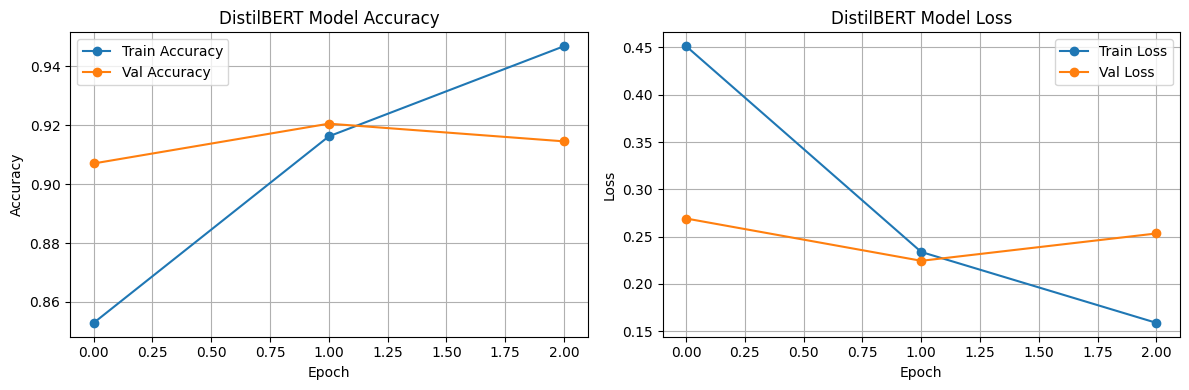

Final Training Accuracy:   0.9468
Final Validation Accuracy: 0.9145


In [30]:
# 5.4 Training curves

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Plot accuracy
axes[0].plot(history_bert.history['accuracy'], label='Train Accuracy', marker='o')
axes[0].plot(history_bert.history['val_accuracy'], label='Val Accuracy', marker='o')
axes[0].set_title('DistilBERT Model Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True)

# Plot loss
axes[1].plot(history_bert.history['loss'], label='Train Loss', marker='o')
axes[1].plot(history_bert.history['val_loss'], label='Val Loss', marker='o')
axes[1].set_title('DistilBERT Model Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.savefig('reports/bert_training_history.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Final Training Accuracy:   {history_bert.history['accuracy'][-1]:.4f}")
print(f"Final Validation Accuracy: {history_bert.history['val_accuracy'][-1]:.4f}")

## 5.5 Evaluation

In [24]:
# 5.5 Save the trained model
model_bert.save('models/bert_model')

print("Model saved to models/bert_model")

INFO:tensorflow:Assets written to: models/bert_model\assets


INFO:tensorflow:Assets written to: models/bert_model\assets


Model saved to models/bert_model


In [25]:
# 5.5 Evaluation on the full test set
test_loss, test_accuracy = model_bert.evaluate(
    [test_encodings['input_ids'], test_encodings['attention_mask']],
    test_labels,
    batch_size=32
)

print(f"Test Loss:     {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

238/238 [==============================] - 9s 30ms/step - loss: 0.2821 - accuracy: 0.9051
Test Loss:     0.2821
Test Accuracy: 0.9051


## 5.6 Confusion Matrix

238/238 [==============================] - 8s 28ms/step


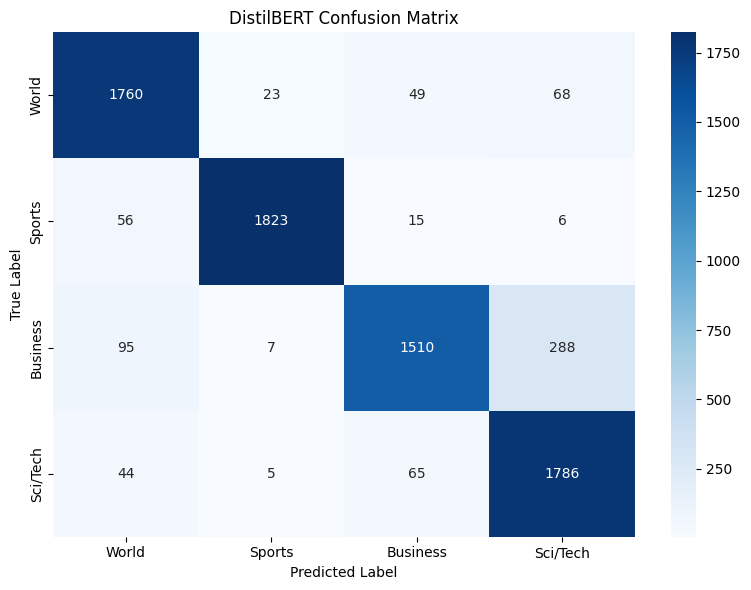

Confusion matrix saved


In [26]:
# 5.6 Confusion Matrix
category_names = ['World', 'Sports', 'Business', 'Sci/Tech']

# Get predictions from the model
raw_predictions = model_bert.predict(
    [test_encodings['input_ids'], test_encodings['attention_mask']],
    batch_size=32
)

# Extract class with highest score
predicted_labels = np.argmax(raw_predictions.logits, axis=1)

# Build and plot the confusion matrix
cm = confusion_matrix(test_labels, predicted_labels)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=category_names,
            yticklabels=category_names)
plt.title('DistilBERT Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()

plt.savefig('reports/bert_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print("Confusion matrix saved")

## 5.7 Results & Sample Predictions

In [27]:
# 5.7 Print precision, recall and F1 score for each category
report = classification_report(test_labels, predicted_labels, target_names=category_names)
print(report)

              precision    recall  f1-score   support

       World       0.90      0.93      0.91      1900
      Sports       0.98      0.96      0.97      1900
    Business       0.92      0.79      0.85      1900
    Sci/Tech       0.83      0.94      0.88      1900

    accuracy                           0.91      7600
   macro avg       0.91      0.91      0.90      7600
weighted avg       0.91      0.91      0.90      7600



In [28]:
# 5.8 Test the model on 5 real headlines
sample_headlines = [
    "NASA launches new telescope to study distant galaxies",
    "Stock markets fall as inflation fears grow",
    "Brazil wins World Cup in dramatic final",
    "Apple unveils new AI-powered iPhone features",
    "UN holds emergency meeting over Ukraine crisis"
]

true_categories = ['Sci/Tech', 'Business', 'Sports', 'Sci/Tech', 'World']

# Tokenize the headlines
sample_encodings = tokenizer_bert(
    sample_headlines,
    max_length=MAX_LEN,
    truncation=True,
    padding='max_length',
    return_tensors='tf'
)

# Get predictions
sample_preds = model_bert.predict(
    [sample_encodings['input_ids'], sample_encodings['attention_mask']]
)
sample_labels = np.argmax(sample_preds.logits, axis=1)

# Print results
print(f"{'Headline':<50} {'True':<12} {'Predicted'}")
print("-" * 80)
for headline, true, pred in zip(sample_headlines, true_categories, sample_labels):
    predicted_name = category_names[pred]
    match = "correct" if predicted_name == true else "wrong"
    print(f"{headline:<50} {true:<12} {predicted_name}  ({match})")

1/1 [==============================] - 0s 70ms/step
Headline                                           True         Predicted
--------------------------------------------------------------------------------
NASA launches new telescope to study distant galaxies Sci/Tech     Sci/Tech  (correct)
Stock markets fall as inflation fears grow         Business     Business  (correct)
Brazil wins World Cup in dramatic final            Sports       Sports  (correct)
Apple unveils new AI-powered iPhone features       Sci/Tech     Sci/Tech  (correct)
UN holds emergency meeting over Ukraine crisis     World        World  (correct)


# 6. Hyperparameter Tuning
## 6.1 Search Space
## 6.2 Best Configuration
## 6.3 Retrained Final Model

In [ ]:
# TODO: Import keras_tuner
# TODO: Define build_hp_model() with tunable embedding_dim, lstm_units, dropout, learning_rate
# TODO: Run RandomSearch or BayesianOptimization
# TODO: Print best hyperparameters
# TODO: Train final model with best config

# 7. Model Evaluation & Interpretation
## 7.1 Test Set Evaluation
## 7.2 Confusion Matrix
## 7.3 Per-Class Metrics
## 7.4 Scratch vs. BERT Comparison

In [ ]:
# TODO: Load both saved models from models/
# TODO: Evaluate on test set (model.evaluate)
# TODO: Generate predictions (model.predict)
# TODO: Classification report and confusion matrix for both models
# TODO: Create comparison dataframe (Accuracy, F1, Params, Training Time)

# 8. Final Report
## 8.1 Results Interpretation
## 8.2 Hardware & Memory Details
## 8.3 Next Steps
## 8.4 Lessons Learned
## 8.5 Team Contributions

### 8.1 Results Interpretation
*Write your analysis here after running the models. Discuss Business vs Sci/Tech confusion and business impact.*

### 8.2 Hardware & Memory Details
- CPU/GPU used:
- RAM available:
- Training time per epoch (scratch):
- Training time per epoch (BERT):
- Model size on disk:

### 8.3 Next Steps
*Suggestions for continuing the project: real-time API, RSS integration, multi-label support.*

### 8.4 Lessons Learned
*3-5 bullet points on technical and project management takeaways.*

### 8.5 Team Contributions
| Member | Contribution |
|--------|--------------|
| 1 | |
| 2 | |
| 3 | |
| 4 | |
| 5 | |
| 6 | |